In [1]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor, Pool
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingGridSearchCV,KFold

import utils_ml

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
plt.style.use('tableau-colorblind10')
def plot_style():
    font_size       = 12
    dpi             = 200

    params = {'figure.dpi': dpi,
              'savefig.dpi': dpi,
              'font.size': font_size,
              'font.family': "serif",
              'figure.titlesize': font_size,
              'legend.fontsize': font_size,
              'axes.labelsize': font_size,
              'axes.titlesize': font_size,
              'xtick.labelsize': font_size,
              'ytick.labelsize': font_size,
              'text.usetex': True,
             }

    plt.rcParams.update(params)
plot_style()

In [3]:
features_memmap = np.load('data/features_regression_selected.npy', mmap_mode='r')

features_0 = np.array(np.load("data/nfeatures_08/ModEsq00.pkl", allow_pickle=True))
features_1 = np.array(np.load("data/nfeatures_08/ModEsq01.pkl", allow_pickle=True))
features_2 = np.array(np.load("data/nfeatures_08/ModEsq02.pkl", allow_pickle=True))
features_3 = np.array(np.load("data/nfeatures_08/ModEsq03.pkl", allow_pickle=True))
features_4 = np.array(np.load("data/nfeatures_08/ModEsq04.pkl", allow_pickle=True))
features_5 = np.array(np.load("data/nfeatures_08/ModEsq05.pkl", allow_pickle=True))
features_6 = np.array(np.load("data/nfeatures_08/ModEsq06.pkl", allow_pickle=True))
features_7 = np.array(np.load("data/nfeatures_08/ModEsq07.pkl", allow_pickle=True))

all_features = np.concatenate([features_0, features_1, features_2, features_3, 
                               features_4, features_5, features_6, features_7], axis=0)

# features_memmap = np.load('data/features_filtered.npy', mmap_mode='r')
old_label_arr = np.array([np.tile(i,3000) for i in np.arange(0,8)]).flatten()

# Define the mapping from class labels (0 to 7) to the new 3-element array format
# where each element in the array represents the number of poles on [bt], [bb], and [tb]
class_to_poles = {
    0: [1, 0, 0],  # 1 pole on [bt]
    1: [0, 1, 0],  # 1 pole on [bb]
    2: [0, 0, 1],  # 1 pole on [tb]
    3: [1, 1, 0],  # 1 pole on [bt] and 1 pole on [bb]
    4: [0, 1, 1],  # 1 pole on [bb] and 1 pole on [tb]
    5: [1, 1, 1],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 2, 1],  # 2 poles on [bb] and 1 pole on [tb]
    7: [0, 1, 2]   # 1 pole on [bb] and 2 poles on [tb]
}


new_label_arr = utils_ml.convert_labels(old_label_arr, class_to_poles)

X_train_new, X_test_new, y_train, y_test = train_test_split(features_memmap, new_label_arr, test_size=0.1, random_state=42)

In [4]:
# Train Pool for CatBoost (multi-output regression requires separate models per target)
models = []
preds = []
data_uncertainty = []
knowledge_uncertainty = []

for i in range(y_train.shape[1]):
    train_pool = Pool(X_train_new, y_train[:, i])
    val_pool = Pool(X_test_new, y_test[:, i])

    model = CatBoostRegressor(
        iterations=2000,
        depth=10,
        learning_rate=0.1,
        loss_function='RMSEWithUncertainty',
        subsample=0.5,
        bootstrap_type='Bernoulli',
        random_seed=0,
        verbose=100,
        early_stopping_rounds=1000
    )
    model.fit(train_pool, eval_set=val_pool, use_best_model=False)
    models.append(model)

    # Generate predictions with uncertainty
    pred = model.virtual_ensembles_predict(X_test_new, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
    preds.append(pred[:, 0])  # Mean predictions
    data_uncertainty.append(pred[:, 2])  # Data uncertainty
    knowledge_uncertainty.append(pred[:, 1])  # Knowledge uncertainty

# Convert lists to arrays for easier manipulation
preds = np.column_stack(preds)
data_uncertainty = np.column_stack(data_uncertainty)
knowledge_uncertainty = np.column_stack(knowledge_uncertainty)



0:	learn: 0.6146989	test: 0.6056056	best: 0.6056056 (0)	total: 366ms	remaining: 12m 12s
100:	learn: -2.0666848	test: -1.8072693	best: -1.8072693 (100)	total: 34.3s	remaining: 10m 44s
200:	learn: -2.2738717	test: -1.8020084	best: -1.8304628 (138)	total: 1m 7s	remaining: 10m 7s
300:	learn: -2.4003546	test: -1.6644033	best: -1.8304628 (138)	total: 1m 41s	remaining: 9m 32s
400:	learn: -2.5123767	test: -1.4355651	best: -1.8304628 (138)	total: 2m 14s	remaining: 8m 57s
500:	learn: -2.6061264	test: -1.0554432	best: -1.8304628 (138)	total: 2m 47s	remaining: 8m 22s
600:	learn: -2.6910508	test: -0.5565979	best: -1.8304628 (138)	total: 3m 21s	remaining: 7m 48s
700:	learn: -2.7577993	test: 0.0577735	best: -1.8304628 (138)	total: 3m 54s	remaining: 7m 13s
800:	learn: -2.8182145	test: 0.9197757	best: -1.8304628 (138)	total: 4m 26s	remaining: 6m 38s
900:	learn: -2.8667503	test: 1.7678018	best: -1.8304628 (138)	total: 4m 58s	remaining: 6m 4s
1000:	learn: -2.9072238	test: 2.7567551	best: -1.8304628 (138)

In [5]:
search_hyp = False
if search_hyp:

    # Train Pool for CatBoost (multi-output regression requires separate models per target)
    models = []
    preds = []
    data_uncertainty = []
    knowledge_uncertainty = []

    param_grid = {
        'iterations': [500, 1000, 1500],
        'learning_rate': [0.01, 0.1, 0.2],
        'depth': [6, 8, 10],
        'subsample': [0.5, 0.7, 1.0],
        'bootstrap_type': ['Bernoulli']
    }

    # cv = KFold(n_splits=5, shuffle=True, random_state=0)


    for i in range(y_train.shape[1]):
        train_pool = Pool(X_train_new, y_train[:, i])
        val_pool = Pool(X_test_new, y_test[:, i])

        model = CatBoostRegressor(
            loss_function='RMSEWithUncertainty',
            random_seed=0,
            verbose=100
            )
        
        cv_results = model.grid_search(param_grid,
                    X=train_pool,
                    cv=2,
                    partition_random_seed=0,
                    calc_cv_statistics=True,
                    search_by_train_test_split=True,
                    refit=True,
                    shuffle=True,
                    stratified=None,
                    train_size=0.8,
                    verbose=True,
                    plot=True)

        # Generate predictions with uncertainty
        pred = model.virtual_ensembles_predict(X_test_new, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
        preds.append(pred[:, 0])  # Mean predictions
        data_uncertainty.append(pred[:, 2])  # Data uncertainty
        knowledge_uncertainty.append(pred[:, 1])  # Knowledge uncertainty
         

    # Convert lists to arrays for easier manipulation
    preds = np.column_stack(preds)
    data_uncertainty = np.column_stack(data_uncertainty)
    knowledge_uncertainty = np.column_stack(knowledge_uncertainty)



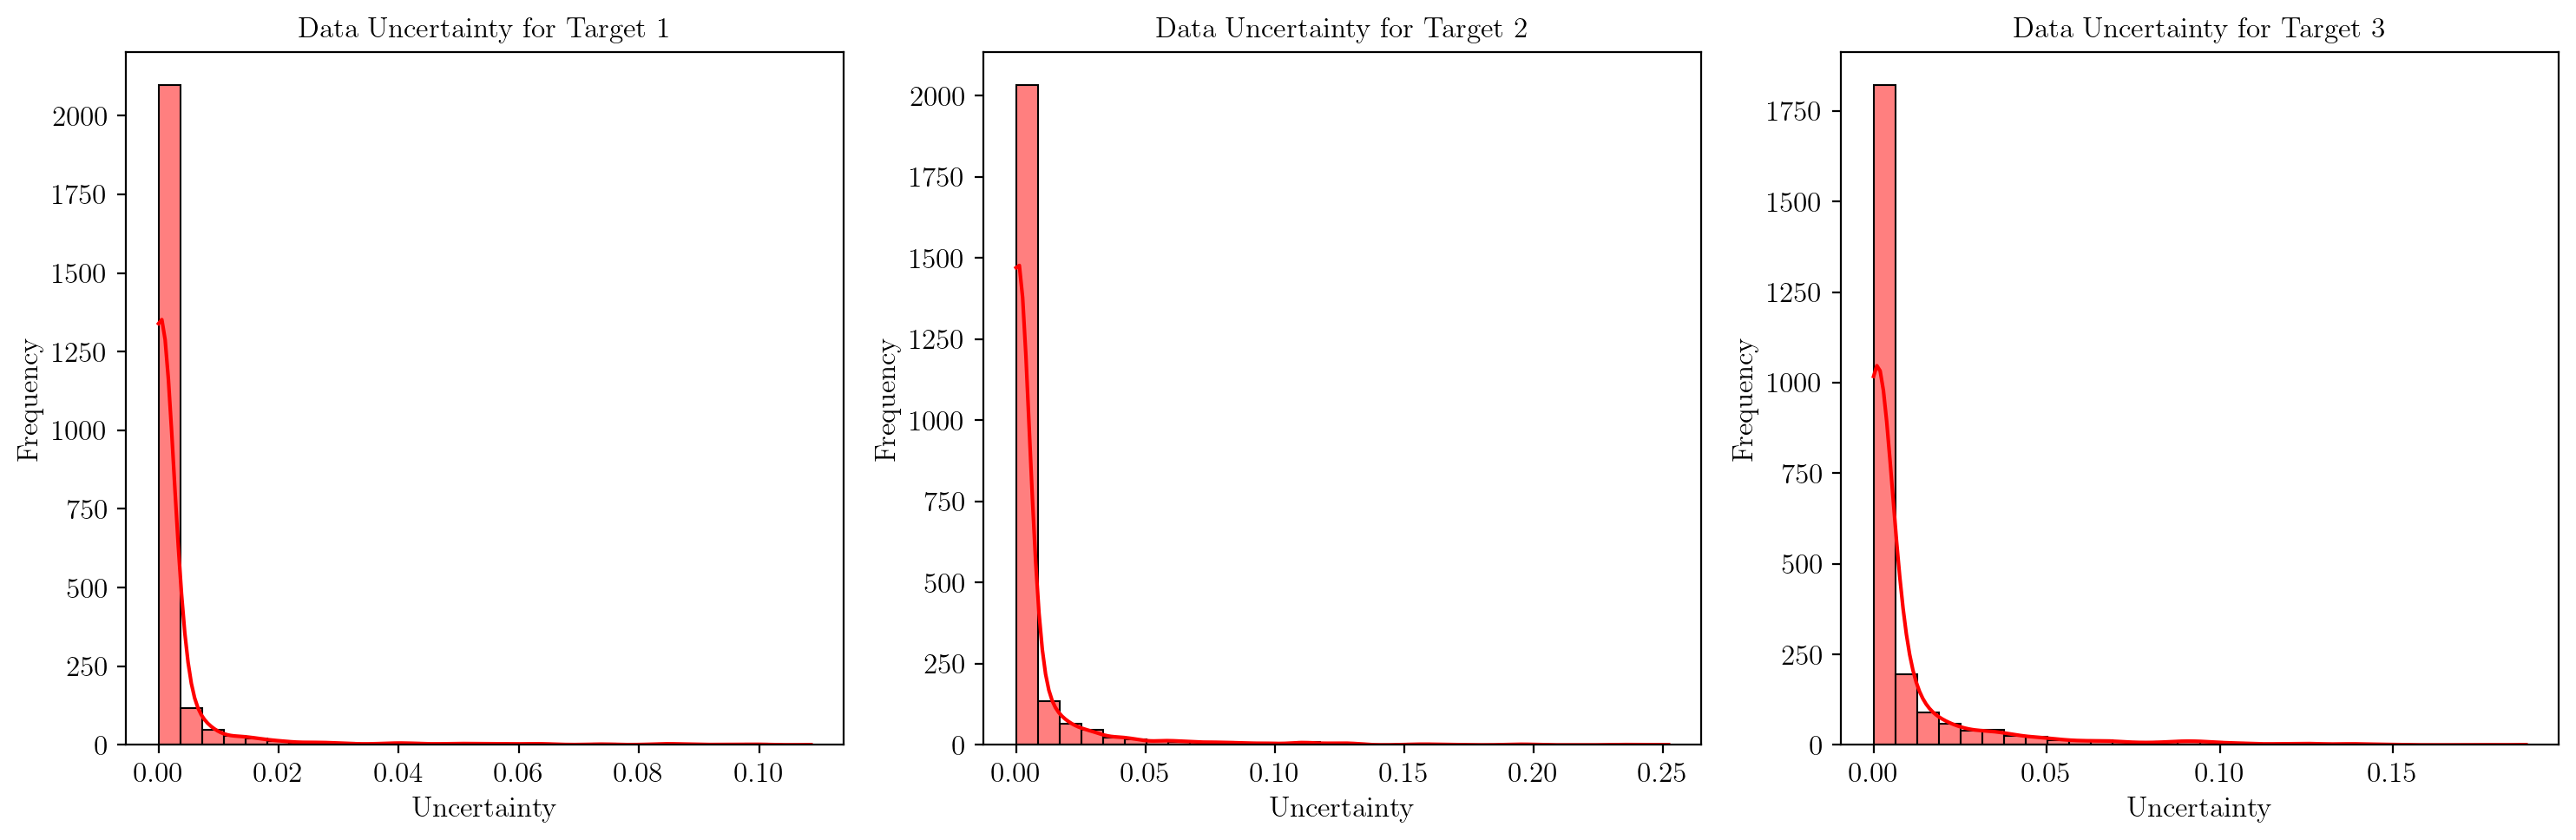

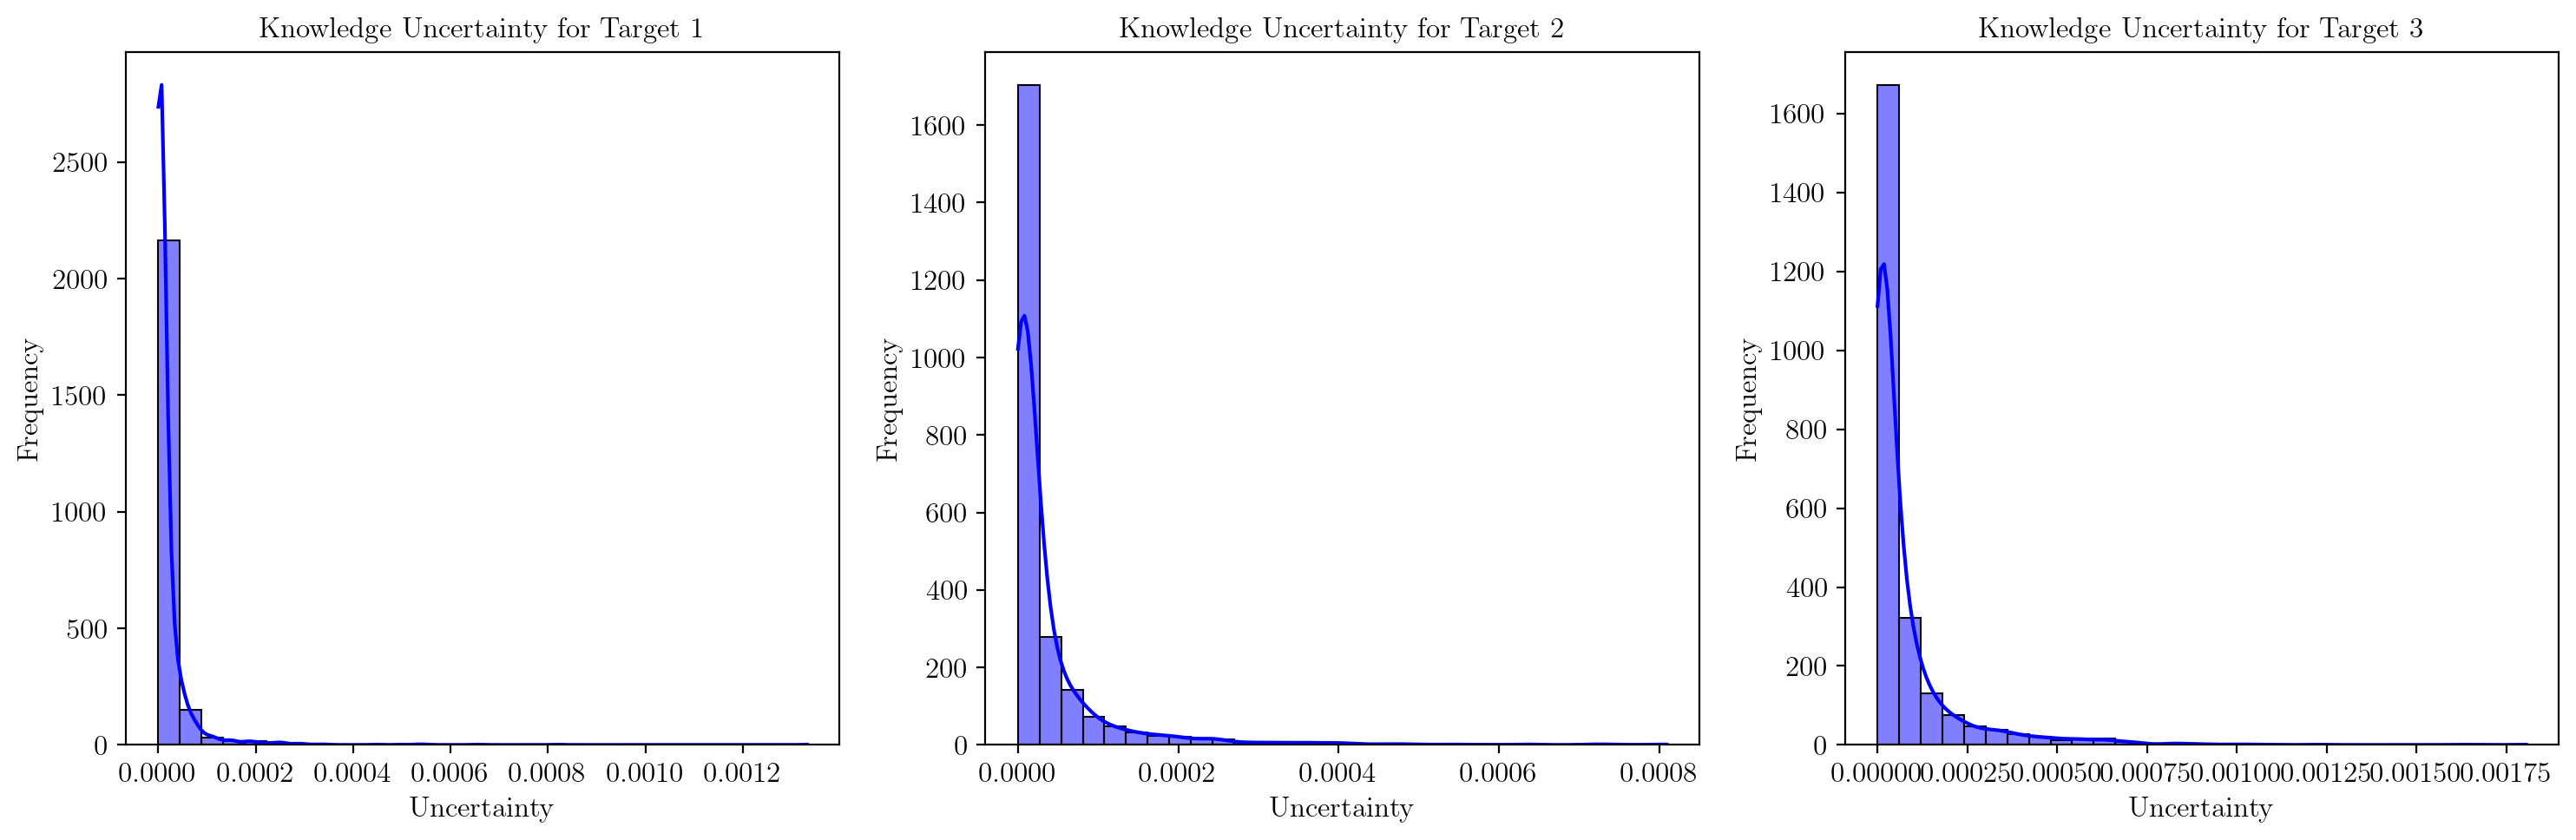

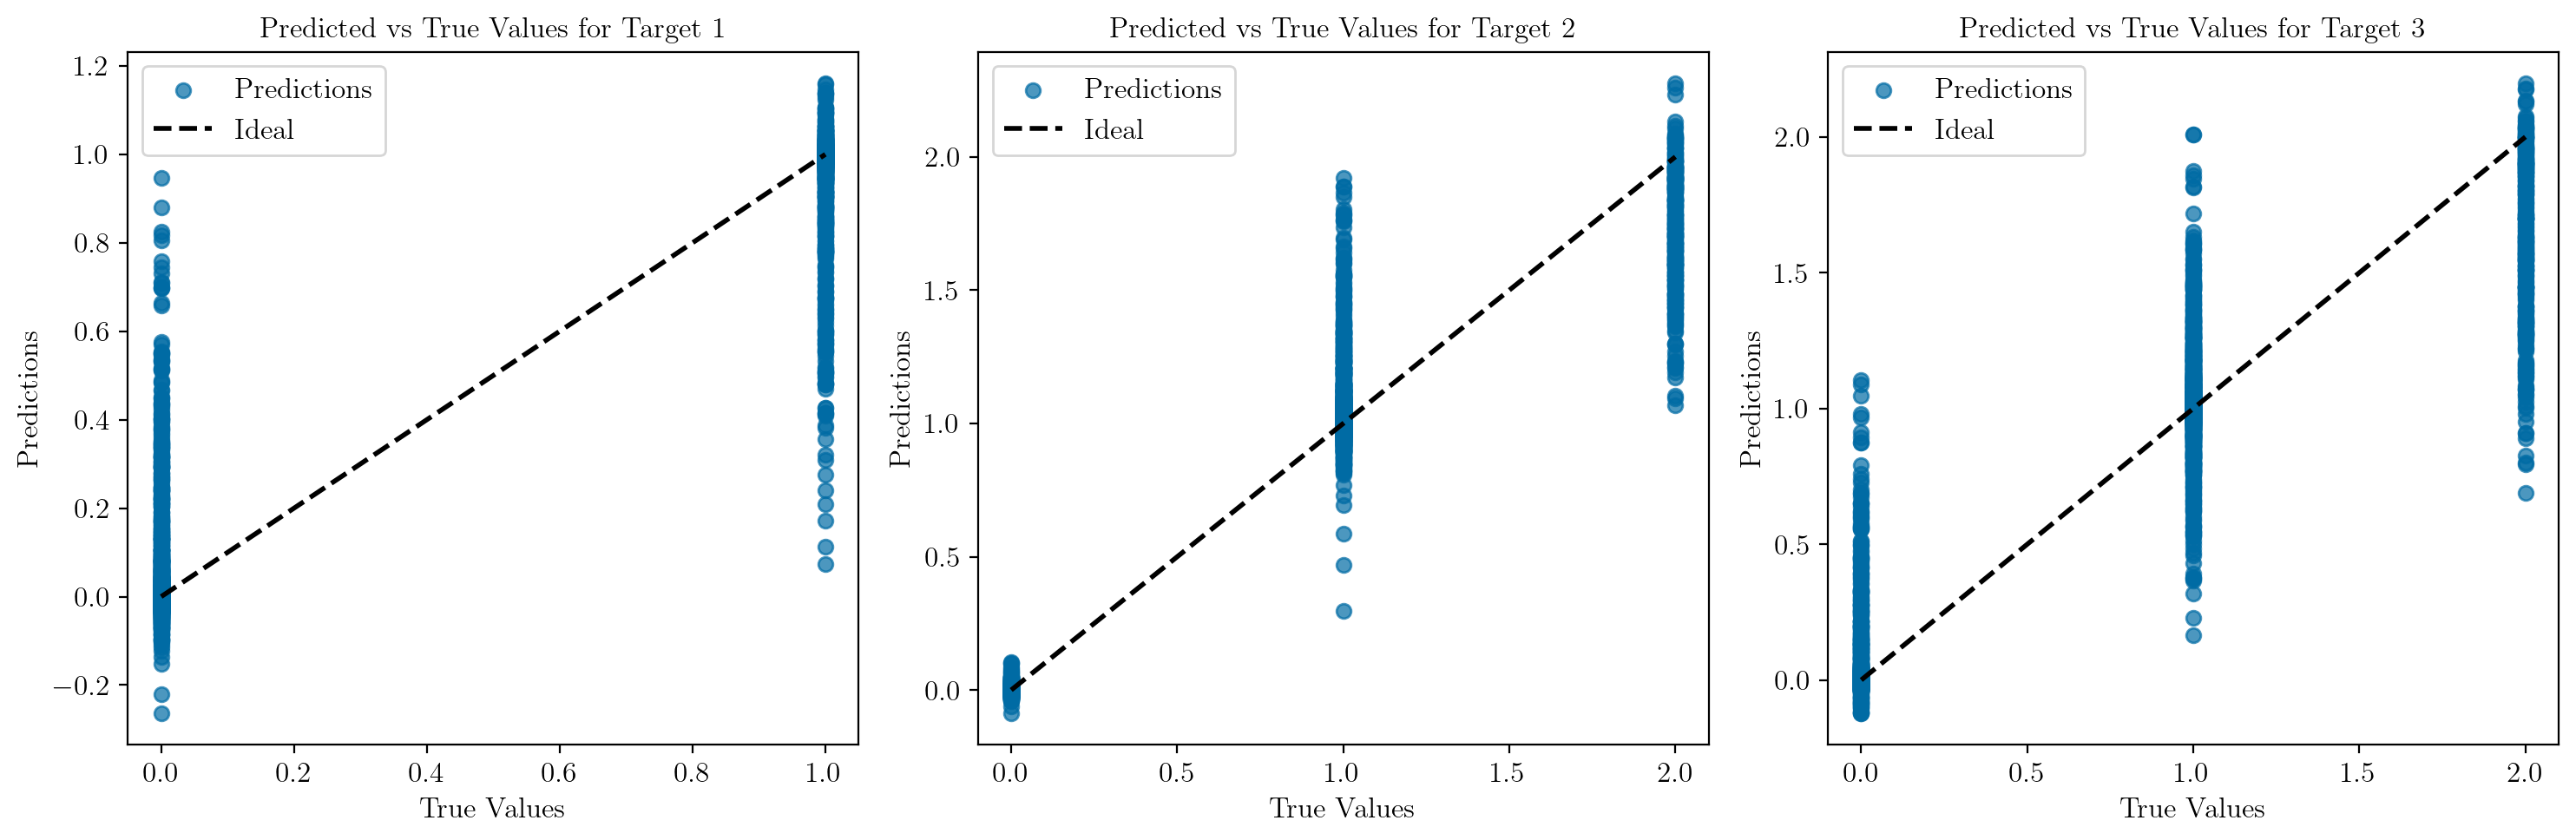

In [6]:
# Aggregate plots for data uncertainty
plt.figure(figsize=(15, 5))
for i in range(y_train.shape[1]):
    plt.subplot(1, 3, i + 1)
    sns.histplot(data_uncertainty[:, i], kde=True, bins=30, color='red')
    plt.title(f"Data Uncertainty for Target {i+1}")
    plt.xlabel("Uncertainty")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Aggregate plots for knowledge uncertainty
plt.figure(figsize=(15, 5))
for i in range(y_train.shape[1]):
    plt.subplot(1, 3, i + 1)
    sns.histplot(knowledge_uncertainty[:, i], kde=True, bins=30, color='blue')
    plt.title(f"Knowledge Uncertainty for Target {i+1}")
    plt.xlabel("Uncertainty")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Aggregate scatter plots for predictions vs. true values
plt.figure(figsize=(15, 5))
for i in range(y_train.shape[1]):
    plt.subplot(1, 3, i + 1)
    plt.scatter(y_test[:, i], preds[:, i], alpha=0.7, label="Predictions")
    plt.plot([y_test[:, i].min(), y_test[:, i].max()], [y_test[:, i].min(), y_test[:, i].max()], 'k--', lw=2, label="Ideal")
    plt.title(f"Predicted vs True Values for Target {i+1}")
    plt.xlabel("True Values")
    plt.ylabel("Predictions")
    plt.legend()
plt.tight_layout()
plt.show()

# Uncer vs MSE

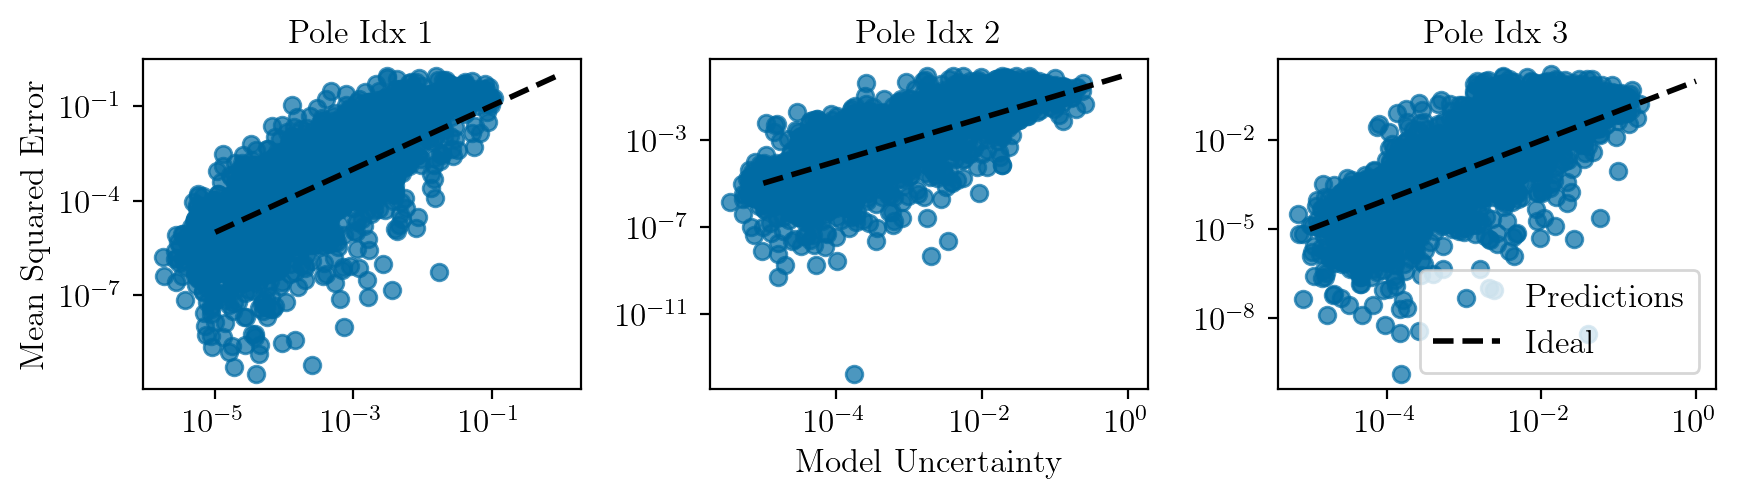

In [7]:
# Aggregate scatter plots for predictions vs. true values
# plt.subplots(1,figsize=(3.54331, 3.54331*0.75))
plt.figure(figsize=(3.54331*2.5, 3.54331*0.75))
for i in range(y_train.shape[1]):
    plt.subplot(1, 3, i + 1)
    plt.scatter(data_uncertainty[:, i], (y_test[:, i]- preds[:, i])**2, alpha=0.7, label="Predictions")
    # plt.errorbar(y_test[:, i], preds[:, i], xerr=data_uncertainty[:, i],alpha=0.7, label="Predictions", fmt=".")
    plt.plot([1e-5,1 ], [1e-5,1], 'k--', lw=2, label="Ideal")
    plt.title(f"Pole Idx {i+1}")
    if i == 1:
        plt.xlabel("Model Uncertainty")
    
    if i == 0:
        plt.ylabel("Mean Squared Error ")

    plt.yscale("log")
    plt.xscale("log")
plt.legend()
plt.tight_layout()
plt.show()

# Training Threshold

In [8]:
preds_train = []
data_uncertainty_train = []
knowledge_uncertainty_train = []

for i in range(y_train.shape[1]):
    train_pool = Pool(X_train_new, y_train[:, i])
    val_pool = Pool(X_test_new, y_test[:, i])

    model = models[i]

    # Generate predictions with uncertainty
    pred_train = model.virtual_ensembles_predict(X_train_new, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
    preds_train.append(pred_train[:, 0])  # Mean predictions
    data_uncertainty_train.append(pred_train[:, 2])  # Data uncertainty
    knowledge_uncertainty_train.append(pred_train[:, 1])  # Knowledge uncertainty

# Convert lists to arrays for easier manipulation
preds_train = np.column_stack(preds_train)
data_uncertainty_train = np.column_stack(data_uncertainty_train)
knowledge_uncertainty_train = np.column_stack(knowledge_uncertainty_train)

In [9]:
optimized_thresholds = utils_ml.optimize_thresholds(preds_train, y_train, class_to_poles)
print("Optimized Thresholds:", optimized_thresholds)

Optimization result:        message: Optimization terminated successfully.
       success: True
        status: 0
           fun: -0.9902314814814814
             x: [ 4.940e-01  4.975e-01  5.098e-01  4.919e-01  5.133e-01
                  5.174e-01  4.720e-01  5.175e-01]
           nit: 32
          nfev: 130
 final_simplex: (array([[ 4.940e-01,  4.975e-01, ...,  4.720e-01,
                         5.175e-01],
                       [ 4.941e-01,  4.975e-01, ...,  4.720e-01,
                         5.175e-01],
                       ...,
                       [ 4.940e-01,  4.975e-01, ...,  4.720e-01,
                         5.175e-01],
                       [ 4.940e-01,  4.975e-01, ...,  4.720e-01,
                         5.175e-01]]), array([-9.902e-01, -9.902e-01, -9.902e-01, -9.902e-01,
                       -9.902e-01, -9.902e-01, -9.902e-01, -9.902e-01,
                       -9.902e-01]))
Optimized Thresholds: [0.49404769 0.49749821 0.50983155 0.49185006 0.51330425 0.517389

In [10]:
adjusted_preds_train = utils_ml.round_with_thresholds(preds_train, optimized_thresholds, class_to_poles)

res_ = np.sum(np.sum(np.round(preds_train) == y_train, axis=1) == 3)/y_train.shape[0]
print(f"Test Accuracy Baselie: {np.mean(res_):.4f}")

res_ = np.sum(np.sum(adjusted_preds_train == y_train, axis=1) == 3)/y_train.shape[0]
print(f"Test Accuracy Improved: {np.mean(res_):.4f}")

Test Accuracy Baselie: 0.9897
Test Accuracy Improved: 0.9902


In [11]:
adjusted_preds = utils_ml.round_with_thresholds(preds, optimized_thresholds, class_to_poles)

res_ = np.sum(np.sum(np.round(preds) == y_test, axis=1) == 3)/y_test.shape[0]
print(f"Test Accuracy Baselie: {np.mean(res_):.4f}")

res_ = np.sum(np.sum(adjusted_preds == y_test, axis=1) == 3)/y_test.shape[0]
print(f"Test Accuracy Improved: {np.mean(res_):.4f}")

Test Accuracy Baselie: 0.8938
Test Accuracy Improved: 0.8950


In [12]:
Test Accuracy Baselie: 0.9281
Test Accuracy Improved: 0.9326

Test Accuracy Baselie: 0.8554
Test Accuracy Improved: 0.8638

SyntaxError: invalid syntax (193319511.py, line 1)

# Removing

/tmp/ipykernel_193632/1589510332.py:22: RuntimeWarning: invalid value encountered in scalar divide
  acc = np.sum(remaining_true == np.round(remaining_preds)) /remaining_preds.shape[0]


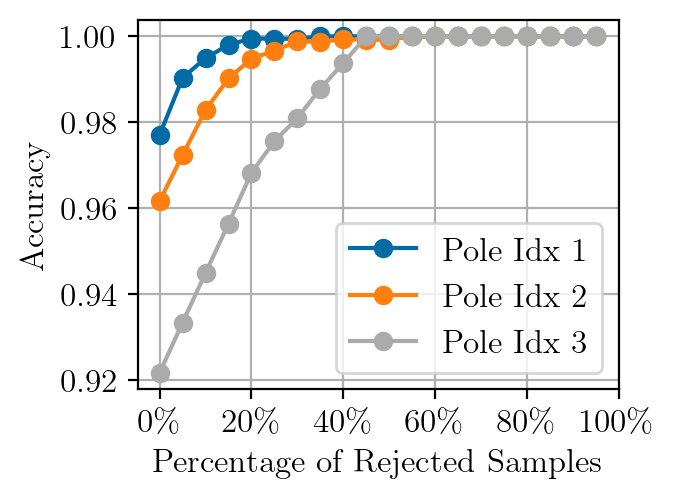

In [13]:
# Sort the data by uncertainty for each target
mse_changes = []
percent_removed = []

for i in range(y_train.shape[1]):
    sorted_indices = np.argsort(data_uncertainty[:, i])[::-1] 
    sorted_uncertainties = data_uncertainty[sorted_indices, i]
    sorted_true = y_test[sorted_indices, i]
    sorted_preds = preds[sorted_indices, i]

    # Calculate the MSE after removing samples with the highest uncertainty
    acc_list = []
    percent_list = []
    total_samples = len(sorted_uncertainties)

    for remove_percent in range(0, 101, 5):  # Remove in 5% increments
        num_remove = int(total_samples * (remove_percent / 100))
        remaining_true = sorted_true[num_remove:]
        remaining_preds = sorted_preds[num_remove:]

        # mse = np.mean((remaining_true - remaining_preds) ** 2)  # Calculate MSE
        acc = np.sum(remaining_true == np.round(remaining_preds)) /remaining_preds.shape[0]
        acc_list.append(acc)
        percent_list.append(remove_percent)
        

    mse_changes.append(acc_list)
    percent_removed.append(percent_list)

# Plot the results
# plt.figure(figsize=(15, 5))
fig, axs = plt.subplots(1,figsize=(3.54331, 3.54331*0.75))

for i in range(y_train.shape[1]):
    axs.plot(percent_removed[i], mse_changes[i],"-o", label=f"Pole Idx {i+1}")
axs.set_xlabel("Percentage of Rejected Samples")
axs.set_ylabel("Accuracy")
# axs.set_title("Impact of Removing High-Uncertainty Samples on Acc")
axs.legend()
axs.set_xticks([0, 20, 40, 60, 80, 100])
axs.set_xticklabels([f"{int(p)}\%" for p in [0, 20, 40, 60, 80, 100]])
axs.grid(True)
fig.tight_layout()
# fig.show()

# Hist

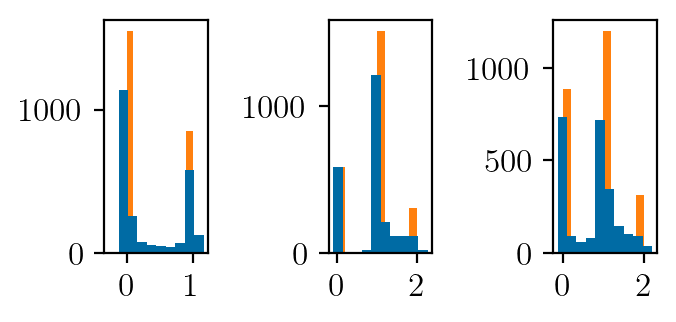

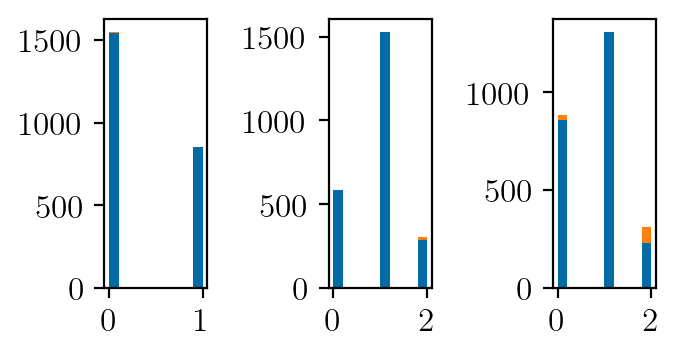

In [14]:
fig, axs = plt.subplots(1,3,figsize=(3.54331, 3.54331*0.5))


axs[0].hist((preds[:,0]))
axs[0].hist(y_test[:,0],zorder=0)

axs[1].hist((preds[:,1]))
axs[1].hist(y_test[:,1],zorder=0)

axs[2].hist((preds[:,2]))
axs[2].hist(y_test[:,2],zorder=0)

fig.tight_layout()

fig, axs = plt.subplots(1,3,figsize=(3.54331, 3.54331*0.55))

axs[0].hist(np.round(preds[:,0]))
axs[0].hist(y_test[:,0],zorder=0)

axs[1].hist(np.round(preds[:,1]))
axs[1].hist(y_test[:,1],zorder=0)

axs[2].hist(np.round(preds[:,2]))
axs[2].hist(y_test[:,2],zorder=0)

fig.tight_layout()

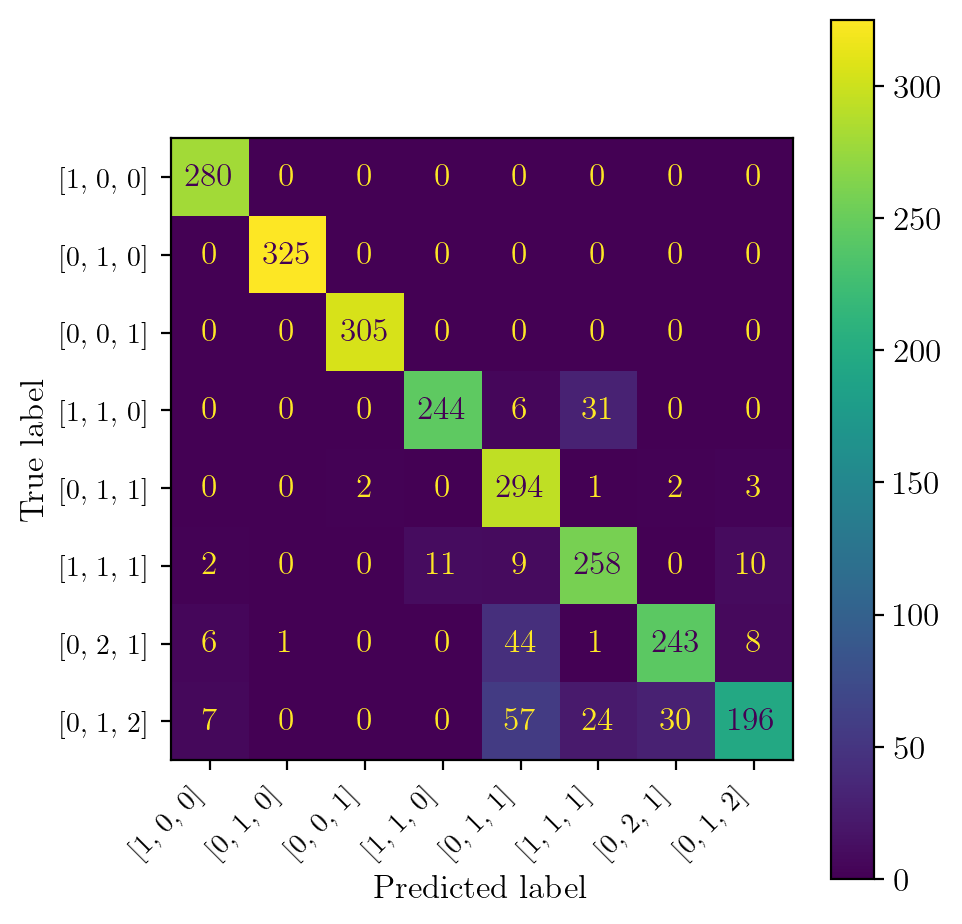

In [15]:
custom_labels = [str(class_to_poles[i]) for i in range(len(class_to_poles))]

# Compute the confusion matrix
predictions = utils_ml.reconvert_labels(np.abs(np.round(preds)).tolist(), class_to_poles)
cm = confusion_matrix(utils_ml.reconvert_labels(y_test, class_to_poles), predictions, labels=np.arange(len(class_to_poles)))

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(len(class_to_poles)))
fig, ax = plt.subplots(figsize=(5, 5))  # Adjust figure size if needed
disp.plot(ax=ax)

# Update x and y axis tick labels with the custom labels
ax.set_xticks(np.arange(len(custom_labels)))
ax.set_yticks(np.arange(len(custom_labels)))
ax.set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(custom_labels, fontsize=10)

# Adjust layout for readability
plt.tight_layout()
plt.show()

# Anomaly detection

In [41]:
ext_old_label_arr = np.array([np.tile(i,np.load(f"{'dataExt/P'}{0:02d}{'_intensity.pkl'}", allow_pickle=True).shape[0]) for i in np.arange(35)]).flatten()
ext_class_to_poles = {
    0: [0, 0, 0],  # 1 pole on [bt]
    1: [1, 0, 0],  # 1 pole on [bb]
    2: [0, 1, 0],  # 1 pole on [tb]
    3: [0, 0, 1],  # 1 pole on [bt] and 1 pole on [bb]
    4: [2, 0, 0],  # 1 pole on [bb] and 1 pole on [tb]
    5: [0, 2, 0],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 0, 2],  # 2 poles on [bb] and 1 pole on [tb]
    7: [1, 1, 0],   # 1 pole on [bb] and 2 poles on [tb]
    8: [1, 0, 1],
    9: [0, 1, 1],
    10: [3, 0, 0],
    11: [0, 3, 0],
    12: [0, 0, 3],
    13: [2, 1, 0],
    14: [2, 0, 1],
    15: [1, 2, 0],
    16: [0, 2, 1],
    17: [1, 0, 2],
    18: [0, 1, 2],
    19: [1, 1, 1],
    20: [4, 0, 0],
    21: [0, 4, 0],
    22: [0, 0, 4],
    23: [3, 1, 0],
    24: [3, 0, 1],
    25: [1, 3, 0],
    26: [0, 3, 1],
    27: [1, 0, 3],
    28: [0, 1, 3],
    29: [2, 2, 0],
    30: [2, 0, 2],
    31: [0, 2, 2],
    32: [2, 1, 1],
    33: [1, 2, 1],
    34: [1, 1, 2],
}



ext_label_arr = utils_ml.convert_labels(ext_old_label_arr, ext_class_to_poles)
ext_features_memmap = np.load('dataExt/features_filtered.npy', mmap_mode='r+')

In [81]:
ext_X_outside = ext_features_memmap[np.where((ext_label_arr == [2,0,0]).all(axis=1))[0]]
ext_y_outside = ext_label_arr[np.where((ext_label_arr == [2,0,0]).all(axis=1))[0]]

ext_X_inside = features_memmap[np.where((new_label_arr == [1,0,0]).all(axis=1))[0]]
ext_y_inside = new_label_arr[np.where((new_label_arr == [1,0,0]).all(axis=1))[0]]

In [82]:
extented_preds_outside = []
extented_data_uncertainty_outside = []
extented_knowledge_uncertainty_outside = []

extented_preds_inside = []
extented_data_uncertainty_inside = []
extented_knowledge_uncertainty_inside = []

for i in range(y_train.shape[1]):
    
    model = models[i]

    # Generate predictions with uncertainty
    pred_outside = model.virtual_ensembles_predict(ext_X_outside, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
    extented_preds_outside.append(pred_outside[:, 0])  # Mean predictions
    extented_data_uncertainty_outside.append(pred_outside[:, 2])  # Data uncertainty
    extented_knowledge_uncertainty_outside.append(pred_outside[:, 1])  # Knowledge uncertainty

        # Generate predictions with uncertainty
    pred_inside = model.virtual_ensembles_predict(ext_X_inside, prediction_type='TotalUncertainty', virtual_ensembles_count=10)
    extented_preds_inside.append(pred_inside[:, 0])  # Mean predictions
    extented_data_uncertainty_inside.append(pred_inside[:, 2])  # Data uncertainty
    extented_knowledge_uncertainty_inside.append(pred_inside[:, 1])  # Knowledge uncertainty

# Convert lists to arrays for easier manipulation
extented_preds_outside = np.column_stack(extented_preds_outside)
extented_data_uncertainty_outside = np.column_stack(extented_data_uncertainty_outside)
extented_knowledge_uncertainty_outside = np.column_stack(extented_knowledge_uncertainty_outside)

# Convert lists to arrays for easier manipulation
extented_preds_inside = np.column_stack(extented_preds_inside)
extented_data_uncertainty_inside = np.column_stack(extented_data_uncertainty_inside)
extented_knowledge_uncertainty_inside = np.column_stack(extented_knowledge_uncertainty_inside)

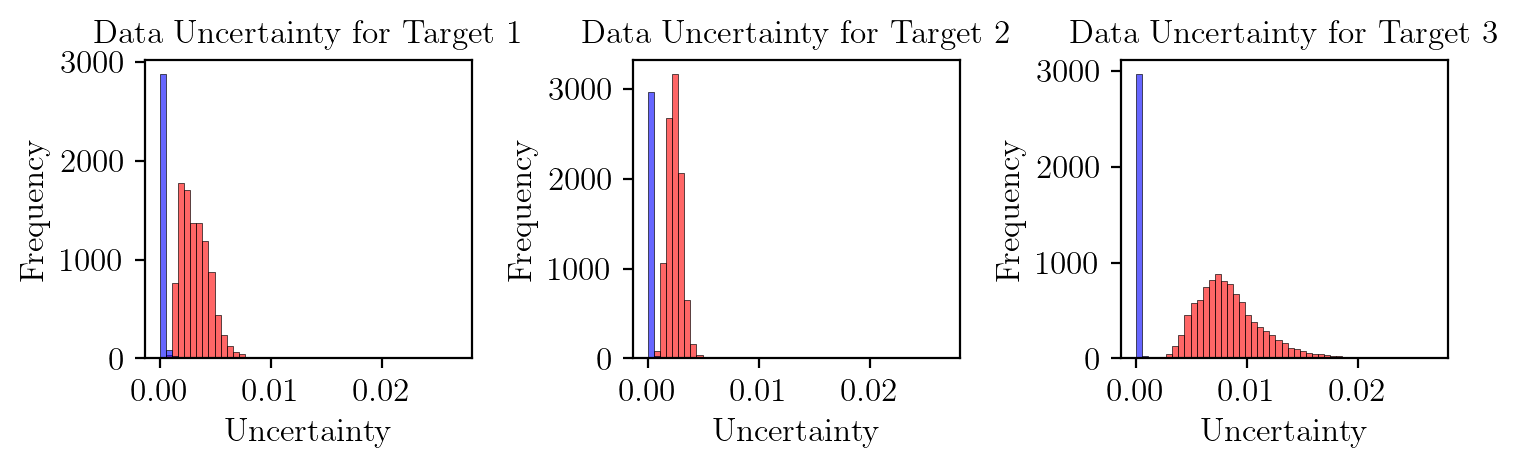

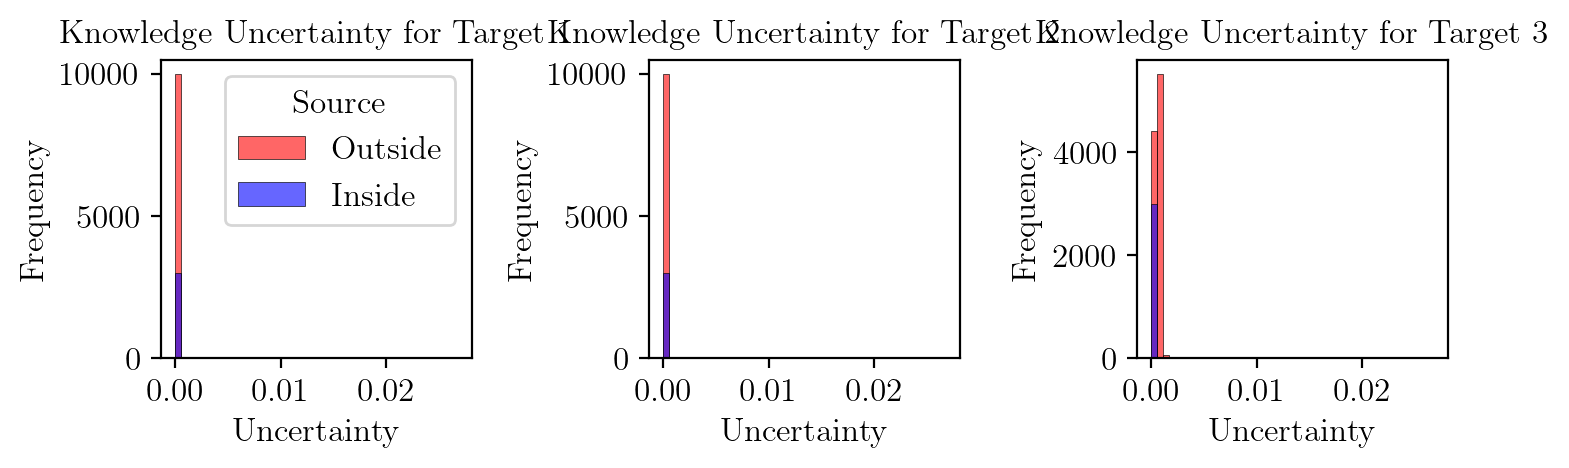

In [83]:
# Define a shared bin range
bins = np.linspace(
    min(extented_data_uncertainty_outside.min(), extented_data_uncertainty_inside.min(),
        extented_knowledge_uncertainty_outside.min(), extented_knowledge_uncertainty_inside.min()),
    max(extented_data_uncertainty_outside.max(), extented_data_uncertainty_inside.max(),
        extented_knowledge_uncertainty_outside.max(), extented_knowledge_uncertainty_inside.max()),
    50
)

# Plot Data Uncertainty
plt.figure(figsize=(15/2, 5/2))
for i in range(y_train.shape[1]):
    plt.subplot(1, 3, i + 1)
    sns.histplot(extented_data_uncertainty_outside[:, i], kde=False, bins=bins, color='red', label="Outside", alpha=0.6)
    sns.histplot(extented_data_uncertainty_inside[:, i], kde=False, bins=bins, color='blue', label="Inside", alpha=0.6)
    plt.title(f"Data Uncertainty for Target {i+1}")
    plt.xlabel("Uncertainty")
    plt.ylabel("Frequency")
    # if i == 0:  # Add legend to the first subplot only
    #     plt.legend(title="Source")
plt.tight_layout()
plt.show()

# Plot Knowledge Uncertainty
plt.figure(figsize=(15/2, 5/2))
for i in range(y_train.shape[1]):
    plt.subplot(1, 3, i + 1)
    sns.histplot(extented_knowledge_uncertainty_outside[:, i], kde=False, bins=bins, color='red', label="Outside", alpha=0.6)
    sns.histplot(extented_knowledge_uncertainty_inside[:, i], kde=False, bins=bins, color='blue', label="Inside", alpha=0.6)
    plt.title(f"Knowledge Uncertainty for Target {i+1}")
    plt.xlabel("Uncertainty")
    plt.ylabel("Frequency")
    if i == 0:  # Add legend to the first subplot only
        plt.legend(title="Source")
plt.tight_layout()
plt.show()
